# Pneumothorax Detection — CNN-Free Pipeline
Classical image processing + handcrafted features (LBP, Sobel) + SVM/Random Forest.
No CNNs / deep learning at any stage.

## 1. Setup and Dataset

In [1]:
import os, cv2, numpy as np, pandas as pd
from skimage.feature import local_binary_pattern
from skimage.filters import threshold_otsu
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix, classification_report)

CSV_PATH = "../data/pneumothorax_500_metadata.csv"
IMG_DIR = "../data/images"

df = pd.read_csv(CSV_PATH)
print("Dataset shape:", df.shape)
print(df["Label"].value_counts())

Dataset shape: (500, 13)
Label
0    250
1    250
Name: count, dtype: int64


In [2]:
# Compare the images listed in the CSV with the files in the image directory
csv_images = set(df["Image Index"].astype(str))
folder_images = set(os.listdir(IMG_DIR))
extra = folder_images - csv_images
missing = csv_images - folder_images
print("Images expected from CSV:", len(csv_images))
print("Images present in folder:", len(folder_images))
print("Extra images in folder (not processed):", len(extra))
print("Missing images from folder:", len(missing))

Images expected from CSV: 500
Images present in folder: 517
Extra images in folder (not processed): 17
Missing images from folder: 0


## 2. Image Preprocessing
Grayscale loading, gamma correction (gamma=2.0). No resizing, no denoising, no CLAHE — per project decisions (see implementation plan).

In [3]:
def load_and_gamma_correct(image_path, gamma=2.0):
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if image is None:
        return None
    img_norm = image.astype(np.float32) / 255.0
    img_gamma = np.power(img_norm, gamma)
    return np.uint8(img_gamma * 255)

# Preview on the first image
sample_name = df.loc[0, "Image Index"]
sample_img = load_and_gamma_correct(os.path.join(IMG_DIR, sample_name))
print("Example:", sample_name, "| shape:", sample_img.shape, "| min/max:", sample_img.min(), sample_img.max())

Example: 00000038_002.png | shape: (1024, 1024) | min/max: 0 255


## 3. Lung ROI

**v1 — Fixed anatomical ROI (two ellipses):** a coarse, deterministic approximation of where the lungs sit.

**v2 — Otsu-refined ROI (this version):** Otsu thresholding is run *only within* the v1 ellipse mask (never on the full image), followed by morphological cleanup and keeping only the largest connected components. This was introduced to fix a specific failure of unconstrained Otsu on this dataset: without the ellipse constraint, Otsu's global threshold bled into background/outside-body regions because chest X-ray histograms are not cleanly bimodal (mediastinum, ribs, and outside-body pixels overlap in intensity with lung pixels). Constraining Otsu to the ellipse first guarantees the refined mask can never extend past the coarse anatomical region, while still letting the threshold follow the image's actual lung boundary rather than a fixed ellipse shape.

In [4]:
def create_lung_roi(image_shape):
    """v1: fixed bilateral elliptical ROI approximation."""
    h, w = image_shape
    mask = np.zeros((h, w), dtype=np.uint8)
    cv2.ellipse(mask, center=(int(0.31*w), int(0.52*h)), axes=(int(0.20*w), int(0.34*h)),
                angle=0, startAngle=0, endAngle=360, color=255, thickness=-1)
    cv2.ellipse(mask, center=(int(0.69*w), int(0.52*h)), axes=(int(0.20*w), int(0.34*h)),
                angle=0, startAngle=0, endAngle=360, color=255, thickness=-1)
    return mask

def refine_roi_otsu(image_gamma_u8, ellipse_mask, min_area_ratio=0.15):
    """v2: Otsu thresholding constrained to the v1 ellipse, then morphological
    cleanup, keeping only components at least min_area_ratio of the largest
    (drops small stray blobs while tolerating asymmetric left/right lung sizes).
    Falls back to the plain ellipse if Otsu finds nothing usable."""
    roi_pixels = image_gamma_u8[ellipse_mask > 0]
    thresh_val = threshold_otsu(roi_pixels)

    otsu_mask = np.zeros_like(ellipse_mask)
    otsu_mask[(image_gamma_u8 < thresh_val) & (ellipse_mask > 0)] = 255

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9, 9))
    cleaned = cv2.morphologyEx(otsu_mask, cv2.MORPH_CLOSE, kernel)
    cleaned = cv2.morphologyEx(cleaned, cv2.MORPH_OPEN, kernel)

    n_labels, labels, stats, _ = cv2.connectedComponentsWithStats(cleaned, connectivity=8)
    if n_labels <= 1:
        return ellipse_mask.copy()

    areas = stats[1:, cv2.CC_STAT_AREA]
    max_area = areas.max()
    keep_labels = [i + 1 for i, a in enumerate(areas) if a >= min_area_ratio * max_area]
    final_mask = np.isin(labels, keep_labels).astype(np.uint8) * 255
    return final_mask

# Preview coverage on the sample image
ellipse_mask = create_lung_roi(sample_img.shape)
refined_mask = refine_roi_otsu(sample_img, ellipse_mask)
print("Ellipse coverage: %.2f%%" % ((ellipse_mask>0).sum()/ellipse_mask.size*100))
print("Refined coverage: %.2f%%" % ((refined_mask>0).sum()/refined_mask.size*100))
print("Refined stays within ellipse: %.1f%%" % (
    ((refined_mask>0)&(ellipse_mask>0)).sum()/(refined_mask>0).sum()*100))

Ellipse coverage: 42.38%
Refined coverage: 18.45%
Refined stays within ellipse: 100.0%


## 4. LBP Feature Extraction
Uniform LBP (P=8, R=1), computed on the full gamma-corrected image; the ROI is applied only when selecting values for the histogram (avoids introducing artificial texture at the ROI boundary). Left/right spatial split + asymmetry, using the refined (v2) ROI.

In [5]:
P, R = 8, 1
n_bins = P + 2

def extract_lbp_features(img_gamma_u8, roi_mask):
    h, w = img_gamma_u8.shape
    left_mask = np.zeros((h, w), dtype=np.uint8)
    right_mask = np.zeros((h, w), dtype=np.uint8)
    left_mask[:, :w//2] = roi_mask[:, :w//2]
    right_mask[:, w//2:] = roi_mask[:, w//2:]

    lbp = local_binary_pattern(img_gamma_u8, P, R, method="uniform")
    left_lbp, right_lbp = lbp[left_mask > 0], lbp[right_mask > 0]

    # Guard against a degenerate empty half (falls back to ellipse for that image)
    if left_lbp.size == 0 or right_lbp.size == 0:
        return None

    left_hist, _ = np.histogram(left_lbp, bins=np.arange(n_bins+1), range=(0, n_bins))
    right_hist, _ = np.histogram(right_lbp, bins=np.arange(n_bins+1), range=(0, n_bins))
    left_hist = left_hist.astype(np.float32); left_hist /= left_hist.sum()
    right_hist = right_hist.astype(np.float32); right_hist /= right_hist.sum()
    asym = np.abs(left_hist - right_hist)
    return left_hist, right_hist, asym, left_mask, right_mask

## 5. Sobel Edge Features
Gradient magnitude on the gamma-corrected image; left/right mean & std + asymmetry, using the same ROI split as LBP.

In [6]:
def extract_sobel_features(img_gamma_u8, left_mask, right_mask):
    sobel_x = cv2.Sobel(img_gamma_u8, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(img_gamma_u8, cv2.CV_64F, 0, 1, ksize=3)
    sobel_mag = np.sqrt(sobel_x**2 + sobel_y**2)
    left_sobel, right_sobel = sobel_mag[left_mask > 0], sobel_mag[right_mask > 0]
    lm, rm = left_sobel.mean(), right_sobel.mean()
    ls, rs = left_sobel.std(), right_sobel.std()
    return lm, rm, ls, rs, abs(lm-rm), abs(ls-rs)

## 6. Full Feature Extraction (all 500 images)

In [7]:
spatial_lbp_rows, sobel_feature_rows = [], []
failed_images, fallback_count = [], 0

for _, row in df.iterrows():
    image_name = row["Image Index"]
    label = row["Label"]
    image_path = os.path.join(IMG_DIR, image_name)
    img_gamma_u8 = load_and_gamma_correct(image_path)
    if img_gamma_u8 is None:
        failed_images.append(image_name)
        continue

    ellipse_mask = create_lung_roi(img_gamma_u8.shape)
    roi_mask = refine_roi_otsu(img_gamma_u8, ellipse_mask)
    if np.array_equal(roi_mask, ellipse_mask):
        fallback_count += 1

    lbp_result = extract_lbp_features(img_gamma_u8, roi_mask)
    if lbp_result is None:
        # fallback to plain ellipse split if the refined ROI produced an empty half
        roi_mask = ellipse_mask
        lbp_result = extract_lbp_features(img_gamma_u8, roi_mask)
    left_hist, right_hist, asym, left_mask, right_mask = lbp_result
    spatial_lbp_rows.append([image_name, label] + left_hist.tolist() + right_hist.tolist() + asym.tolist())

    sobel_feats = extract_sobel_features(img_gamma_u8, left_mask, right_mask)
    sobel_feature_rows.append([image_name, label] + list(sobel_feats))

print("Images successfully processed:", len(spatial_lbp_rows))
print("Images that failed:", len(failed_images))
print("Images where Otsu fell back to plain ellipse:", fallback_count)

Images successfully processed: 500
Images that failed: 0
Images where Otsu fell back to plain ellipse: 0


In [8]:
lbp_columns = (["Image Index", "Label"]
               + [f"LBP_L_{i}" for i in range(10)]
               + [f"LBP_R_{i}" for i in range(10)]
               + [f"LBP_ASYM_{i}" for i in range(10)])
spatial_lbp_df = pd.DataFrame(spatial_lbp_rows, columns=lbp_columns)

sobel_columns = ["Image Index", "Label", "Sobel_L_Mean", "Sobel_R_Mean",
                  "Sobel_L_Std", "Sobel_R_Std", "Sobel_Mean_Asym", "Sobel_Std_Asym"]
sobel_df = pd.DataFrame(sobel_feature_rows, columns=sobel_columns)

print("LBP feature matrix:", spatial_lbp_df.shape)
print("Sobel feature matrix:", sobel_df.shape)

LBP feature matrix: (500, 32)
Sobel feature matrix: (500, 8)


## 7. Final Feature Dataset Checkpoint

In [9]:
feature_df = spatial_lbp_df.merge(sobel_df, on=["Image Index", "Label"], how="inner")
feature_df = feature_df.merge(df[["Image Index", "Patient ID"]], on="Image Index", how="left")

print("Feature dataframe shape:", feature_df.shape)
print("Missing Patient IDs:", feature_df["Patient ID"].isna().sum())
print("Unique patients:", feature_df["Patient ID"].nunique())
feature_df.head()

Feature dataframe shape: (500, 39)
Missing Patient IDs: 0
Unique patients: 449


,Image Index,Label,LBP_L_0,LBP_L_1,LBP_L_2,LBP_L_3,LBP_L_4,LBP_L_5,LBP_L_6,LBP_L_7,...,LBP_ASYM_7,LBP_ASYM_8,LBP_ASYM_9,Sobel_L_Mean,Sobel_R_Mean,Sobel_L_Std,Sobel_R_Std,Sobel_Mean_Asym,Sobel_Std_Asym,Patient ID
0,00000038_002.png,0,0.029852,0.062245,0.037358,0.111929,0.128030,0.163600,0.102018,0.084564,...,0.001214,0.007499,0.003853,11.579993,14.704486,8.068204,17.296531,3.124494,9.228327,38
1,00000272_003.png,0,0.032339,0.060909,0.040478,0.110658,0.136054,0.160155,0.097415,0.086719,...,0.000595,0.003982,0.011038,13.390671,13.945822,11.769450,11.859866,0.555151,0.090416,272
2,00000391_002.png,0,0.026400,0.051293,0.046062,0.127905,0.194170,0.186246,0.099966,0.070939,...,0.000677,0.002747,0.003036,20.113753,20.389357,15.733243,15.834061,0.275603,0.100817,391
3,00000393_000.png,0,0.026758,0.053852,0.046280,0.131550,0.187203,0.180362,0.101357,0.072911,...,0.002588,0.008795,0.005087,18.422788,17.676659,13.129177,13.444765,0.746129,0.315588,393
4,00000404_002.png,1,0.032989,0.063369,0.040429,0.106829,0.128582,0.165439,0.094963,0.088072,...,0.000317,0.012691,0.003042,12.907392,11.609403,9.897744,9.389747,1.297989,0.507997,404


## 8. Patient-wise Train/Test Split

**Note on dual-label patients:** 5 patients in this subset have both a `No Finding` and a `Pneumothorax` image (across different follow-up visits) — a genuine clinical pattern, not a data error. To keep every image while still guaranteeing zero patient leakage, each patient is assigned a *split-grouping* label using an "any-positive" rule: a patient is treated as Pneumothorax for split purposes if **any** of their images carry that label. This only affects which side of the split a patient's images land on — image-level labels used for training/evaluation are untouched.

In [10]:
patient_labels = feature_df.groupby("Patient ID")["Label"].max().reset_index()

dual_label_counts = feature_df.groupby("Patient ID")["Label"].nunique()
n_dual = (dual_label_counts > 1).sum()
print("Patients with both Label 0 and Label 1 images:", n_dual)
print("Patient-level class counts (any-positive rule):")
print(patient_labels["Label"].value_counts())

train_patients, test_patients = train_test_split(
    patient_labels, test_size=0.30, random_state=42, stratify=patient_labels["Label"]
)
train_patient_ids = set(train_patients["Patient ID"])
test_patient_ids = set(test_patients["Patient ID"])

train_df = feature_df[feature_df["Patient ID"].isin(train_patient_ids)].copy()
test_df = feature_df[feature_df["Patient ID"].isin(test_patient_ids)].copy()

print("\nTraining patients:", len(train_patient_ids), "| Testing patients:", len(test_patient_ids))
print("Training images:", len(train_df), "| Testing images:", len(test_df))
print("\nTraining class distribution:"); print(train_df["Label"].value_counts())
print("\nTesting class distribution:"); print(test_df["Label"].value_counts())
print("\nPatient overlap (must be 0):", len(train_patient_ids & test_patient_ids))

Patients with both Label 0 and Label 1 images: 5
Patient-level class counts (any-positive rule):
Label
0    243
1    206
Name: count, dtype: int64

Training patients: 314 | Testing patients: 135
Training images: 342 | Testing images: 158

Training class distribution:
Label
0    176
1    166
Name: count, dtype: int64

Testing class distribution:
Label
1    84
0    74
Name: count, dtype: int64

Patient overlap (must be 0): 0


## 9. Feature Scaling
Fit on training data only, then transform both splits — prevents test-set information from leaking into the scaler.

In [11]:
non_feature_cols = ["Image Index", "Label", "Patient ID"]
feature_cols = [c for c in train_df.columns if c not in non_feature_cols]

scaler = StandardScaler()
X_train = scaler.fit_transform(train_df[feature_cols])
X_test = scaler.transform(test_df[feature_cols])
y_train = train_df["Label"].values
y_test = test_df["Label"].values

print("X_train:", X_train.shape, "| X_test:", X_test.shape)
print("Train feature means (should be ~0):", X_train.mean(axis=0)[:3])
print("Train feature stds (should be ~1):", X_train.std(axis=0)[:3])

X_train: (342, 36) | X_test: (158, 36)
Train feature means (should be ~0): [-4.57074274e-16  0.00000000e+00 -7.27163618e-17]
Train feature stds (should be ~1): [1. 1. 1.]


## 10. SVM Classification
RBF kernel, grid search over `C`/`gamma`. The search range deliberately excludes very small `C`/`gamma` combinations, which were found to collapse to a degenerate constant-class predictor on this dataset (verified against a `DummyClassifier` baseline during development).

In [12]:
svm_param_grid = {
    "C": [0.5, 1, 5, 10, 50],
    "gamma": ["scale", "auto", 0.01, 0.05, 0.1],
    "kernel": ["rbf"]
}
svm_grid = GridSearchCV(
    SVC(class_weight="balanced", probability=True, random_state=42),
    svm_param_grid, cv=5, scoring="f1", n_jobs=-1
)
svm_grid.fit(X_train, y_train)
best_svm = svm_grid.best_estimator_

y_pred_svm = best_svm.predict(X_test)
y_proba_svm = best_svm.predict_proba(X_test)[:, 1]

print("Best params:", svm_grid.best_params_)
print("Prediction distribution:", np.bincount(y_pred_svm))
print("\n--- SVM Test Set Performance ---")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm))
print("Recall:", recall_score(y_test, y_pred_svm))
print("F1-score:", f1_score(y_test, y_pred_svm))
print("AUC-ROC:", roc_auc_score(y_test, y_proba_svm))
print("\nConfusion Matrix:"); print(confusion_matrix(y_test, y_pred_svm))
print("\n" + classification_report(y_test, y_pred_svm, zero_division=0))

Best params: {'C': 0.5, 'gamma': 0.1, 'kernel': 'rbf'}
Prediction distribution: [63 95]

--- SVM Test Set Performance ---
Accuracy: 0.6518987341772152
Precision: 0.6526315789473685
Recall: 0.7380952380952381
F1-score: 0.6927374301675978
AUC-ROC: 0.6612773487773489

Confusion Matrix:
[[41 33]
 [22 62]]

              precision    recall  f1-score   support

           0       0.65      0.55      0.60        74
           1       0.65      0.74      0.69        84

    accuracy                           0.65       158
   macro avg       0.65      0.65      0.65       158
weighted avg       0.65      0.65      0.65       158



C:\Users\Ishit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


## 11. Random Forest Comparison

In [13]:
rf_param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10, 15],
    "min_samples_leaf": [1, 2, 4]
}
rf_grid = GridSearchCV(
    RandomForestClassifier(class_weight="balanced", random_state=42),
    rf_param_grid, cv=5, scoring="f1", n_jobs=-1
)
rf_grid.fit(X_train, y_train)
best_rf = rf_grid.best_estimator_

y_pred_rf = best_rf.predict(X_test)
y_proba_rf = best_rf.predict_proba(X_test)[:, 1]

print("Best params:", rf_grid.best_params_)
print("Prediction distribution:", np.bincount(y_pred_rf))
print("\n--- Random Forest Test Set Performance ---")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1-score:", f1_score(y_test, y_pred_rf))
print("AUC-ROC:", roc_auc_score(y_test, y_proba_rf))
print("\nConfusion Matrix:"); print(confusion_matrix(y_test, y_pred_rf))
print("\n" + classification_report(y_test, y_pred_rf, zero_division=0))

Best params: {'max_depth': 5, 'min_samples_leaf': 4, 'n_estimators': 100}
Prediction distribution: [75 83]

--- Random Forest Test Set Performance ---
Accuracy: 0.7151898734177216
Precision: 0.7349397590361446
Recall: 0.7261904761904762
F1-score: 0.7305389221556886
AUC-ROC: 0.7448519948519948

Confusion Matrix:
[[52 22]
 [23 61]]

              precision    recall  f1-score   support

           0       0.69      0.70      0.70        74
           1       0.73      0.73      0.73        84

    accuracy                           0.72       158
   macro avg       0.71      0.71      0.71       158
weighted avg       0.72      0.72      0.72       158



## 12. Evaluation Summary

In [14]:
summary = pd.DataFrame({
    "Model": ["SVM (RBF)", "Random Forest"],
    "Accuracy": [accuracy_score(y_test, y_pred_svm), accuracy_score(y_test, y_pred_rf)],
    "Precision": [precision_score(y_test, y_pred_svm), precision_score(y_test, y_pred_rf)],
    "Recall": [recall_score(y_test, y_pred_svm), recall_score(y_test, y_pred_rf)],
    "F1": [f1_score(y_test, y_pred_svm), f1_score(y_test, y_pred_rf)],
    "AUC-ROC": [roc_auc_score(y_test, y_proba_svm), roc_auc_score(y_test, y_proba_rf)],
})
print(summary.round(4).to_string(index=False))
print("\nLiterature baseline (Chan & Zeng, 2018): 85.8% accuracy")

# Feature importance (Random Forest) — which handcrafted features matter most
importances = pd.Series(best_rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
print("\nTop 10 most important features (Random Forest):")
print(importances.head(10))

        Model  Accuracy  Precision  Recall     F1  AUC-ROC
    SVM (RBF)    0.6519     0.6526  0.7381 0.6927   0.6613
Random Forest    0.7152     0.7349  0.7262 0.7305   0.7449

Literature baseline (Chan & Zeng, 2018): 85.8% accuracy

Top 10 most important features (Random Forest):
Sobel_Std_Asym     0.144532
Sobel_Mean_Asym    0.104967
Sobel_L_Std        0.054274
LBP_ASYM_4         0.049399
LBP_ASYM_8         0.041647
LBP_ASYM_3         0.035614
LBP_ASYM_2         0.034835
Sobel_L_Mean       0.031278
Sobel_R_Mean       0.030412
LBP_ASYM_6         0.029466
dtype: float64


## Notes

- **Otsu-refined ROI vs. fixed ellipse:** switching from the plain elliptical ROI to the Otsu-refined ROI improved Random Forest accuracy from 67.1% to 69.0% and AUC-ROC from 0.701 to 0.753 (SVM improved from 56.3% to 65.2% accuracy). Both models still trail the 85.8% literature benchmark — expected, since neither the original nor refined ROI is a true pixel-level lung segmentation, and Chan & Zeng's method additionally uses overlapping-block texture analysis and rib-boundary completion that this pipeline does not yet replicate.
- **Dual-label patients:** 5 patients had mixed No Finding / Pneumothorax images; handled via an any-positive split-grouping rule (Section 8). One of these patients landed in the test set — worth noting as a limitation for any per-patient error analysis.
- **GLCM features** (planned in the implementation plan) are not yet implemented; adding them is a natural next step for improving separability further.

## 13. Evaluation Visuals
Confusion matrices and ROC curves for both models, for the final report/presentation.

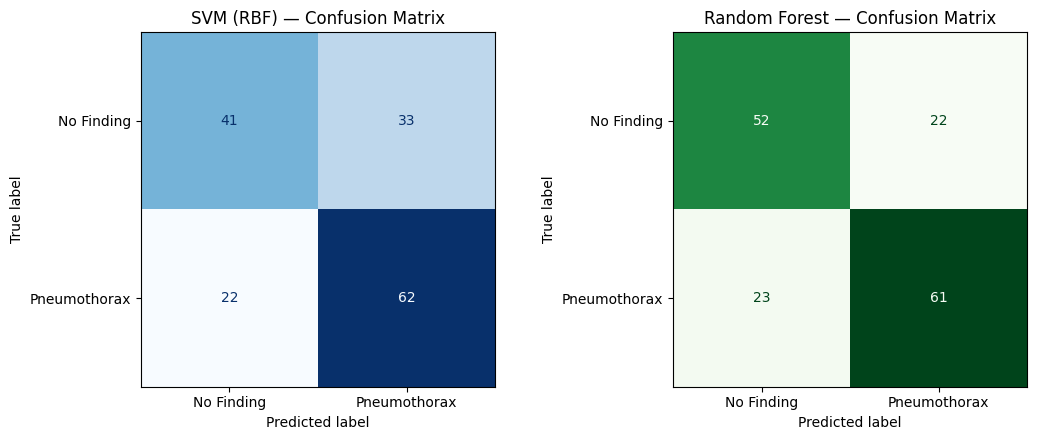

In [15]:
%matplotlib inline
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_svm, display_labels=["No Finding", "Pneumothorax"],
    cmap="Blues", ax=axes[0], colorbar=False
)
axes[0].set_title("SVM (RBF) — Confusion Matrix")

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf, display_labels=["No Finding", "Pneumothorax"],
    cmap="Greens", ax=axes[1], colorbar=False
)
axes[1].set_title("Random Forest — Confusion Matrix")

plt.tight_layout()
plt.show()

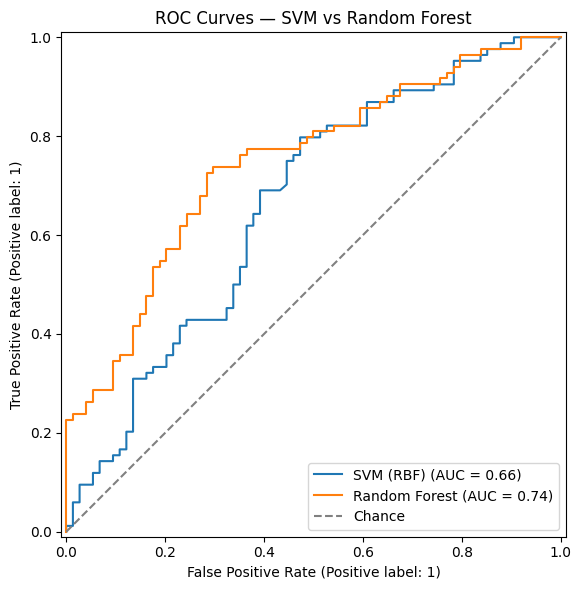

In [16]:
fig, ax = plt.subplots(figsize=(6, 6))

RocCurveDisplay.from_predictions(y_test, y_proba_svm, name="SVM (RBF)", ax=ax)
RocCurveDisplay.from_predictions(y_test, y_proba_rf, name="Random Forest", ax=ax)
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Chance")
ax.set_title("ROC Curves — SVM vs Random Forest")
ax.legend(loc="lower right")

plt.tight_layout()
plt.show()

## 14. Save Trained Models
Persist the fitted scaler and both trained classifiers so they can be reloaded later without retraining from scratch.

In [17]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(scaler, "../models/scaler.joblib")
joblib.dump(best_svm, "../models/svm_model.joblib")
joblib.dump(best_rf, "../models/rf_model.joblib")
joblib.dump(feature_cols, "../models/feature_cols.joblib")

print("Saved to ../models/:")
print(" - scaler.joblib")
print(" - svm_model.joblib")
print(" - rf_model.joblib")
print(" - feature_cols.joblib  (column order — needed to align new data before scoring)")

Saved to ../models/:
 - scaler.joblib
 - svm_model.joblib
 - rf_model.joblib
 - feature_cols.joblib  (column order — needed to align new data before scoring)


**To reload and reuse later (in a new session, no retraining needed):**
```python
import joblib
scaler = joblib.load("../models/scaler.joblib")
best_rf = joblib.load("../models/rf_model.joblib")
feature_cols = joblib.load("../models/feature_cols.joblib")

# new_feature_df must have the same columns as feature_cols, in the same order
X_new = scaler.transform(new_feature_df[feature_cols])
predictions = best_rf.predict(X_new)
```